# 06 発展課題（自作） 解答 — Hfq robustness 窓
対象: [`notebooks/06_hfq_robustness.ipynb`](../notebooks/06_hfq_robustness.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
H,S,M,SH,MH,T,D = (Species(x) for x in ['H','s','m','sH','mH','T','D'])
BETA, KA = 1.0, 1.0
SP = ['H','s','m','sH','mH','T','D']
def R(a,b,k): return ReactionRule(a,b,k)
def build(h_tot, kd=0.3, k5=10.0, a_s=10.0, a_m=10.0, coop=1.0):
    mdl = NetworkModel()
    for r in [R([],[S],a_s), R([],[M],a_m), R([S],[],BETA), R([M],[],BETA),
              R([S,H],[SH],KA), R([SH],[S,H],kd), R([M,H],[MH],KA), R([MH],[M,H],kd),
              R([SH,M],[T],KA*coop), R([T],[SH,M],kd), R([MH,S],[T],KA*coop), R([T],[MH,S],kd),
              R([T],[D,H],k5), R([SH],[H],BETA), R([MH],[H],BETA), R([T],[H],BETA), R([D],[],BETA)]:
        mdl.add_reaction_rule(r)
    return mdl
def pct_duplex(h_tot, **kw):
    v = dict(zip(SP, run_simulation(400.0, y0={'H':h_tot}, model=build(h_tot,**kw), solver='ode', ndiv=1, species_list=SP).as_array()[-1][1:]))
    tot = v['m']+v['mH']+v['T']+v['D']; return 100*v['D']/tot if tot>0 else 0.0

## Q1. `K5`（duplex 形成の速さ）を上げると釣鐘の高さ・窓は?

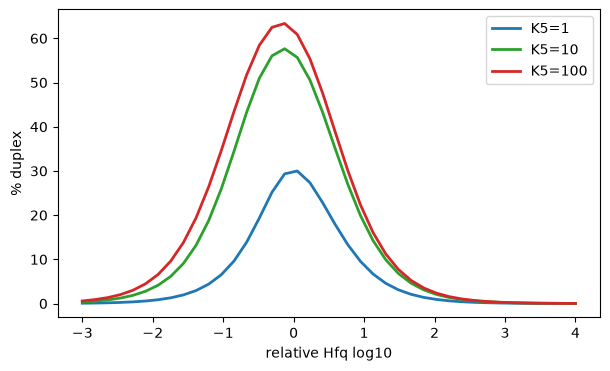

In [2]:
rel = np.logspace(-3,4,40); fig, ax = plt.subplots(figsize=(7,4))
for k5, c in [(1.0,'C0'),(10.0,'C2'),(100.0,'C3')]:
    y=[pct_duplex(r*10, k5=k5) for r in rel]; ax.plot(np.log10(rel), y, color=c, lw=2, label=f'K5={k5:.0f}')
ax.set_xlabel('relative Hfq log10'); ax.set_ylabel('% duplex'); ax.legend(); plt.show()

**答**: `K5` を上げると釣鐘の**ピークが高くなり、窓が高 Hfq 側へ広がる**。K5 が大きい＝三者複合体が速く duplex になって Hfq を返す＝Hfq recycling が速いので、隔離に陥りにくい。論文の「$k_5$（duplex 形成/放出）が Hfq robustness を上げる」効果と一致。

## Q2. 転写量を非対称（A_S=30, A_M=10）にすると最適 Hfq・ピークは?

symmetric a_s=a_m=10: peak %duplex=57.7 at relHfq=0.74
asymmetric a_s=30, a_m=10: peak %duplex=83.3 at relHfq=1.70


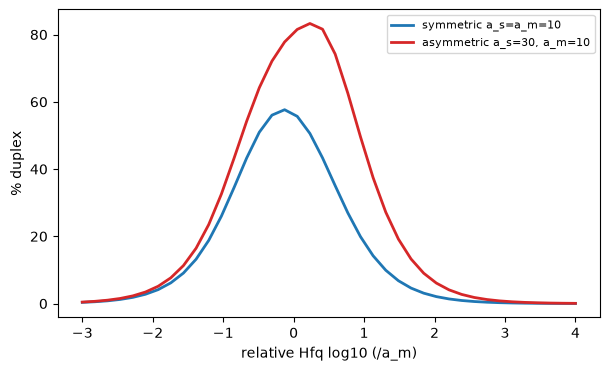

In [3]:
fig, ax = plt.subplots(figsize=(7,4))
for a_s, c, lab in [(10.0,'C0','symmetric a_s=a_m=10'), (30.0,'C3','asymmetric a_s=30, a_m=10')]:
    y=[pct_duplex(r*10, a_s=a_s) for r in rel]
    ax.plot(np.log10(rel), y, color=c, lw=2, label=lab)
    ipk=int(np.argmax(y)); print(f'{lab}: peak %duplex={y[ipk]:.1f} at relHfq={rel[ipk]:.2f}')
ax.set_xlabel('relative Hfq log10 (/a_m)'); ax.set_ylabel('% duplex'); ax.legend(fontsize=8); plt.show()

**答**: sRNA を過剰（a_s=30）にすると、標的 mRNA のより多くが duplex になれるので**ピーク %duplex は上がる**。一方 sRNA が増えた分 Hfq の取り合いが強まり、**最適 Hfq がやや高 Hfq 側へ動く**（sRNA と mRNA 両方を載せるのに Hfq がより要る）。非対称な転写は「どちらが Hfq を得やすいか」を通じて窓を動かす。

## Q3.（考察）bio-a: 結合親和性 $k_a/k_d$ の系統差 → 窓の横ずれ

**答（考察）**: 釣鐘の位置（最適 Hfq）は、RNA が Hfq に載る/外れる比 $k_a/k_d$ と recycling（$k_5$, kd）で決まる。オーソログ間で **distal/proximal 面や rim の保存が違えば有効 $k_a/k_d$ が変わり、最適 Hfq 窓が横にずれ、幅も変わる**と予測できる。結合が強い（$k_d$ 小）系統は少ない Hfq で機能するが高 Hfq で隔離に陥りやすい（窓が狭い）、解離が速い系統は窓が広い（06 本編の kd 効果）。系統ごとの $k_d$ 差を窓の横ずれ・幅として定量するのが **bio-e**。

## Q4. 協同的結合を足すと窓は広がるか

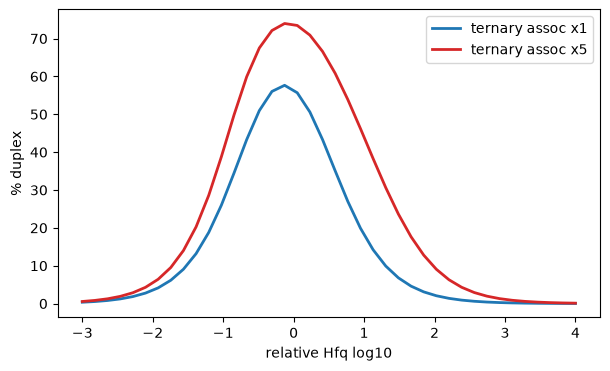

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
for coop, c in [(1.0,'C0'),(5.0,'C3')]:
    y=[pct_duplex(r*10, coop=coop) for r in rel]; ax.plot(np.log10(rel), y, color=c, lw=2, label=f'ternary assoc x{coop:.0f}')
ax.set_xlabel('relative Hfq log10'); ax.set_ylabel('% duplex'); ax.legend(); plt.show()

**答**: 三者複合体形成（第2の結合）を協同的に速める（×5）と、**ピークが上がり窓も広がる**。singly-bound（sH, mH）に囚われた RNA が、パートナーと出会って三者→duplex へ進みやすくなり、隔離から救出されるため。論文 Fig.3-4 の「協同的結合が Hfq robustness を上げる」を最小形で再現。